# Illustratives Beispiel — Drop-Entscheidung: Myopic+ vs. CFA-Future (Greedy)

**Frage:** Wenn eine Störung eingeschoben werden muss und dafür eine Routine-Station gedroppt werden muss (Cheapest-Insertion infeasible) — *welche* Station droppt Myopic+, und welche droppt CFA-Future, und **warum**?

Beide Modelle nutzen den **gleichen Greedy-Cheapest-Insertion-Mechanismus** (`handle_disruptions_greedy` in `src/planning/greedy_routing.py`). Der Unterschied liegt **nur** in der `drop_score_fn`:

| Modell | `drop_score_fn(node)` | Bedeutung |
|---|---|---|
| **Myopic+** | `power_kW / dist(depot, node)` | Rein geometrisch+Leistung: nahe, leistungsstarke Stationen sind "teuer" zu droppen; **`days_since_maintenance` (dsm) spielt keine Rolle** |
| **CFA-Future** | `C̃(node) = θᵀ·φ_scaled(node)` mit `φ = [power_kW, age_years, recovery_curve(dsm), mean_dist_to_others]` | Berücksichtigt alle 4 Features, u. a. `recovery_curve(dsm)` — **wie überfällig** die Station bereits ist |

Niedrigster Score → wird zuerst gedroppt.

> **In diesem Beispiel verwenden wir die echte CFA-Future-Formel**: `θ`, `feature_means` und `feature_stds` werden direkt aus `data/training/cfa_future/theta.json` geladen (θ = [95, 40, 32, 17] für `[power_kW, age_years, recovery_curve, mean_dist_km]`; der `_value()`-Methode von `cfa_future.py` folgend wird der `intercept` nicht addiert — er würde alle `C̃`-Werte nur um eine Konstante verschieben und die Drop-Reihenfolge nicht ändern). Alle 4 Features fließen mit stationsspezifischen Werten ein: `power_kW`, `dsm`/`recovery_curve`, **und zusätzlich** `age_years` (Alter der Station) sowie `mean_dist` (mittlere Distanz zu anderen Stationen) — letztere beiden sind so gewählt, dass sie die Drop-Entscheidung **verstärken**, ohne sie zu dominieren (Station B ist die jüngste und am stärksten isolierte Station, Station A die älteste und am zentralsten gelegene).
>
> Wichtig: `θ_power=95` ist deutlich größer als `θ_recovery_curve=32` — bei zu großem Leistungsunterschied zwischen den Stationen würde CFA-Future trotz hoher Dringlichkeit dieselbe (leistungsschwache) Station droppen wie Myopic+. Die Stationswerte unten sind so gewählt, dass dieser Effekt **nicht** dominiert.

Das folgende synthetische Grid-Beispiel (4 Stationen A–D, Depot, eine eingehende Störung E) zeigt, dass diese unterschiedliche `drop_score_fn` zu **unterschiedlichen Drop-Entscheidungen** führt — und damit zu unterschiedlichen Ausfallkosten.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Synthetisches Grid-Szenario ─────────────────────────────────────────────
# Depot + 4 Routine-Stationen A–D, eine Störung E (rechts außen).
# Konfiguration so gewählt, dass alle drei Modelle im Initialplan
# unterschiedliche Routen bauen UND bei der Drop-Entscheidung unterschiedliche
# Stationen droppen.
depot = (0, 3)
stations = {
    'A': {'pos': (6, 3), 'power': 11,  'dsm': 350, 'age_years': 12, 'mean_dist': 9},
    # AC, fast überfällig (dsm=350), älteste Station, zentral gelegen
    'B': {'pos': (3, 3), 'power': 80,  'dsm': 20,  'age_years': 3,  'mean_dist': 10},
    # DC-Schnelllader (80 kW!), kürzlich gewartet, jung — geometrisch zentral auf der Route
    'C': {'pos': (3, 6), 'power': 22,  'dsm': 180, 'age_years': 8,  'mean_dist': 11},
    # AC, mittel überfällig
    'D': {'pos': (2, 1), 'power': 22,  'dsm': 100, 'age_years': 5,  'mean_dist': 12},
    # AC, relativ frisch, etwas isoliert
}
disruption = {'pos': (8, 2), 'power': 30}

RECOVERY_DAYS = 365
INITIAL_FACTOR = 0.1

def recovery_curve(dsm):
    dsm = min(dsm, RECOVERY_DAYS)
    return INITIAL_FACTOR + (1 - INITIAL_FACTOR) * dsm / RECOVERY_DAYS

def dist(p, q):
    return float(np.hypot(p[0] - q[0], p[1] - q[1]))

# ── Echte CFA-Future-Formel: C̃(node) = θᵀ · φ_scaled(node) ─────────────────
with open(Path('..') / 'data' / 'training' / 'cfa_future' / 'theta.json') as f:
    theta_data = json.load(f)

THETA = np.array(theta_data['theta'])
FEATURE_MEANS = np.array(theta_data['feature_means'])
FEATURE_STDS = np.array(theta_data['feature_stds'])

def c_tilde(power, dsm, age_years, mean_dist):
    phi = np.array([power, age_years, recovery_curve(dsm), mean_dist])
    phi_scaled = (phi - FEATURE_MEANS) / FEATURE_STDS
    return float(THETA @ phi_scaled)

for name, s in stations.items():
    s['recovery_curve'] = recovery_curve(s['dsm'])
    s['c_tilde'] = c_tilde(s['power'], s['dsm'], s['age_years'], s['mean_dist'])
    s['myopic_plus_score'] = s['power'] / max(0.1, dist(depot, s['pos']))
    s['cfa_future_score'] = s['c_tilde']

df = pd.DataFrame(stations).T
df.index.name = 'Station'
print(df[['power', 'dsm', 'age_years', 'mean_dist', 'recovery_curve',
          'c_tilde', 'myopic_plus_score', 'cfa_future_score']].round(2))

drop_myopic_plus = min(stations, key=lambda k: stations[k]['myopic_plus_score'])
drop_cfa = min(stations, key=lambda k: stations[k]['cfa_future_score'])
print(f"\nMyopic+    droppt: {drop_myopic_plus} (niedrigster power/dist-Score)")
print(f"CFA-Future droppt: {drop_cfa} (niedrigster C̃-Score)")

        power  dsm age_years mean_dist recovery_curve    c_tilde  \
Station                                                            
A          11  350        12         9       0.963014  -51.59573   
B          80   20         3        10       0.149315 -54.803993   
C          22  180         8        11       0.543836 -68.628927   
D          22  100         5        12       0.346575 -86.967611   

        myopic_plus_score cfa_future_score  
Station                                     
A                1.833333        -51.59573  
B               26.666667       -54.803993  
C                 5.18545       -68.628927  
D                7.778175       -86.967611  

Myopic+    droppt: A (niedrigster power/dist-Score)
CFA-Future droppt: D (niedrigster C̃-Score)


In [2]:
# ── Initialroute (Nearest-Neighbor ab Depot, für alle Modelle identisch) ─────
remaining = dict(stations)
route = []
cur = depot
while remaining:
    nxt = min(remaining, key=lambda k: dist(cur, remaining[k]['pos']))
    route.append(nxt)
    cur = remaining[nxt]['pos']
    del remaining[nxt]
print("Initialroute:", " → ".join(['Depot'] + route + ['Depot']))

# ── Detour je Station: Einsparung durch Herausnehmen aus der Route ────────────
# Myopic drop_score_fn = det  →  niedrigster Detour wird zuerst gedroppt
route_with_depot = ['Depot'] + route + ['Depot']
def get_pos(name):
    return depot if name == 'Depot' else stations[name]['pos']

for i, name in enumerate(route):
    prev, nxt = route_with_depot[i], route_with_depot[i + 2]
    detour = max(0.0, dist(get_pos(prev), stations[name]['pos'])
                    + dist(stations[name]['pos'], get_pos(nxt))
                    - dist(get_pos(prev), get_pos(nxt)))
    stations[name]['detour_score'] = detour

drop_myopic      = min(stations, key=lambda k: stations[k]['detour_score'])
drop_myopic_plus = min(stations, key=lambda k: stations[k]['myopic_plus_score'])
drop_cfa         = min(stations, key=lambda k: stations[k]['cfa_future_score'])

route_myopic      = [s for s in route if s != drop_myopic]      + ['E']
route_myopic_plus = [s for s in route if s != drop_myopic_plus] + ['E']
route_cfa         = [s for s in route if s != drop_cfa]         + ['E']

print(f"\nMyopic     droppt: {drop_myopic}  (Detour={stations[drop_myopic]['detour_score']:.2f})")
print(f"Myopic+    droppt: {drop_myopic_plus} (niedrigster power/dist-Score)")
print(f"CFA-Future droppt: {drop_cfa}  (niedrigster C̃-Score)")
print(f"\nMyopic     nach Störung:", " → ".join(['Depot'] + route_myopic      + ['Depot']))
print(f"Myopic+    nach Störung:", " → ".join(['Depot'] + route_myopic_plus  + ['Depot']))
print(f"CFA-Future nach Störung:", " → ".join(['Depot'] + route_cfa          + ['Depot']))

Initialroute: Depot → D → B → A → C → Depot

Myopic     droppt: B  (Detour=0.76)
Myopic+    droppt: A (niedrigster power/dist-Score)
CFA-Future droppt: D  (niedrigster C̃-Score)

Myopic     nach Störung: Depot → D → A → C → E → Depot
Myopic+    nach Störung: Depot → D → B → C → E → Depot
CFA-Future nach Störung: Depot → B → A → C → E → Depot


/tmp/ipykernel_6147/74605032.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


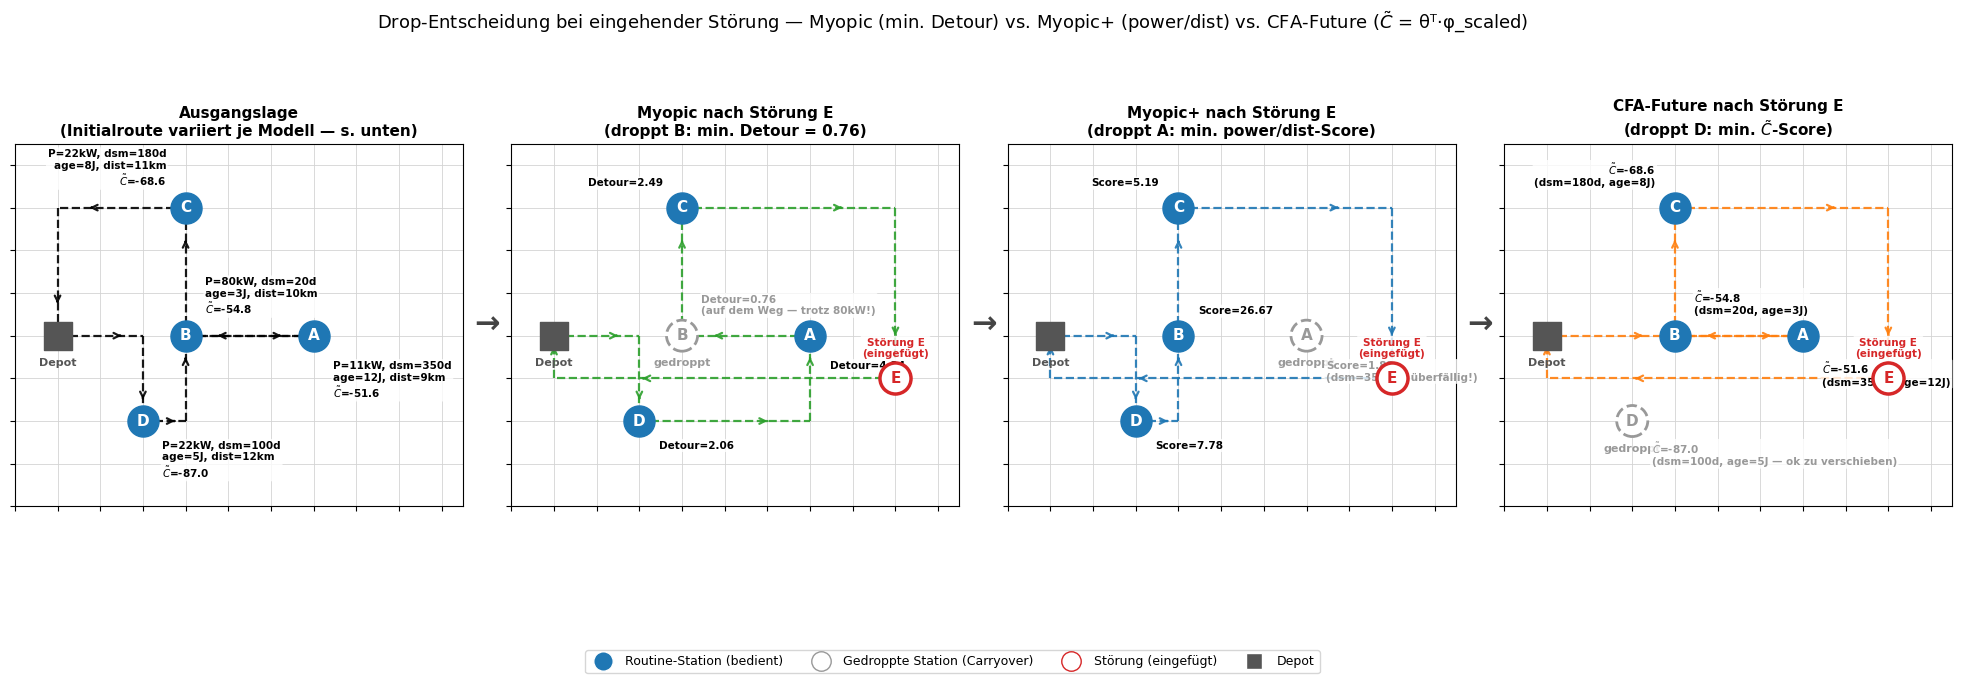

In [3]:
# ── Grid-Visualisierung à la Ulmer et al. (2018), Fig. 1 ────────────────────
STATION_COLOR = '#1f77b4'
DROP_COLOR    = '#999999'
DISRUPTION_COLOR = '#d62728'
MYOPIC_COLOR  = '#2ca02c'

C_TILDE = r'$\tilde{C}$'

all_points = {**{k: v['pos'] for k, v in stations.items()}, 'E': disruption['pos'], 'Depot': depot}

# Offset je Station so, dass Annotations nicht mit Kanten/Knoten kollidieren
LABEL_OFFSETS = {
    'A': dict(dx=14,  dy=-18, ha='left',   va='top'),     # rechts, mittig → nach rechts-unten
    'C': dict(dx=-14, dy=14,  ha='right',  va='bottom'),  # oben-links → nach links-oben
    'D': dict(dx=14,  dy=-14, ha='left',   va='top'),     # unten-links → nach rechts-unten
    'E': dict(dx=0,   dy=14,  ha='center', va='bottom'),
}
DEFAULT_OFFSET = dict(dx=14, dy=14, ha='left', va='bottom')

def draw_grid(ax, title):
    ax.set_xlim(-1, 9.5)
    ax.set_ylim(-1, 7.5)
    ax.set_xticks(range(-1, 10))
    ax.set_yticks(range(-1, 8))
    ax.grid(True, color='lightgray', linewidth=0.6)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold')

def draw_route(ax, route_nodes, color='black', linestyle='--'):
    """Manhattan-Routing (horizontal → vertikal), Pfeilspitze bei ~75% je Segment."""
    pts = [depot] + [all_points[n] for n in route_nodes] + [depot]
    for i in range(len(pts) - 1):
        x1, y1 = pts[i]
        x2, y2 = pts[i + 1]
        segments = []
        if x1 != x2:
            segments.append(((x1, y1), (x2, y1)))
        if y1 != y2:
            segments.append(((x2, y1), (x2, y2)))
        for (sx1, sy1), (sx2, sy2) in segments:
            ax.plot([sx1, sx2], [sy1, sy2], color=color, lw=1.6,
                    linestyle=linestyle, alpha=0.9, zorder=2, solid_capstyle='round')
            ax.annotate('',
                        xy    =(sx1*0.25 + sx2*0.75, sy1*0.25 + sy2*0.75),
                        xytext=(sx1*0.27 + sx2*0.73, sy1*0.27 + sy2*0.73),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.6, alpha=0.9),
                        zorder=3)

def draw_station(ax, name, dropped=False, is_disruption=False, label=None):
    pos = all_points[name]
    display = label if label is not None else name
    if is_disruption:
        ax.scatter(*pos, s=500, marker='o', facecolor='white',
                   edgecolor=DISRUPTION_COLOR, linewidth=2.5, zorder=4)
        ax.annotate(display, pos, ha='center', va='center', fontsize=11,
                    fontweight='bold', color=DISRUPTION_COLOR, zorder=5)
    elif dropped:
        ax.scatter(*pos, s=500, marker='o', facecolor='white',
                   edgecolor=DROP_COLOR, linewidth=2, linestyle='--', zorder=4)
        ax.annotate(display, pos, ha='center', va='center', fontsize=11,
                    fontweight='bold', color=DROP_COLOR, zorder=5)
        ax.annotate('gedroppt', pos, xytext=(0, -22), textcoords='offset points',
                    ha='center', fontsize=8, color=DROP_COLOR, fontweight='bold')
    else:
        ax.scatter(*pos, s=500, marker='o', color=STATION_COLOR, zorder=4)
        ax.annotate(display, pos, ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white', zorder=5)

def draw_depot(ax):
    ax.scatter(*depot, s=400, marker='s', color='#555555', zorder=4)
    ax.annotate('Depot', depot, xytext=(0, -22), textcoords='offset points',
                ha='center', fontsize=8, fontweight='bold', color='#555555')

def annotate_value(ax, name, text, color='black'):
    pos = all_points[name]
    off = LABEL_OFFSETS.get(name, DEFAULT_OFFSET)
    ax.annotate(text, pos, xytext=(off['dx'], off['dy']), textcoords='offset points',
                ha=off['ha'], va=off['va'], fontsize=7.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

# ── Layout: 4 Panels + 3 Pfeil-Trenner ──────────────────────────────────────
fig = plt.figure(figsize=(25, 6.5))
gs = fig.add_gridspec(1, 7, width_ratios=[10, 0.6, 10, 0.6, 10, 0.6, 10], wspace=0.04)
axes = [fig.add_subplot(gs[0, c]) for c in [0, 2, 4, 6]]
for col in [1, 3, 5]:
    ax_sep = fig.add_subplot(gs[0, col])
    ax_sep.axis('off')
    ax_sep.text(0.5, 0.5, '→', fontsize=22, ha='center', va='center',
                transform=ax_sep.transAxes, fontweight='bold', color='#444444')

# ── Panel 0: Ausgangslage (Stationsübersicht, Route = Myopic-Nearest-Neighbor)
ax = axes[0]
draw_grid(ax, 'Ausgangslage\n(Initialroute variiert je Modell — s. unten)')
draw_route(ax, route, color='black')
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name)
    annotate_value(ax, name,
                    f"P={s['power']}kW, dsm={s['dsm']}d\n"
                    f"age={s['age_years']}J, dist={s['mean_dist']}km\n"
                    f"{C_TILDE}={s['c_tilde']:.1f}")

# ── Panel 1: Myopic ───────────────────────────────────────────────────────────
ax = axes[1]
drop_det = stations[drop_myopic]['detour_score']
draw_grid(ax, f'Myopic nach Störung E\n(droppt {drop_myopic}: min. Detour = {drop_det:.2f})')
draw_route(ax, route_myopic, color=MYOPIC_COLOR)
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name, dropped=(name == drop_myopic))
    if name == drop_myopic:
        annotate_value(ax, name,
                       f"Detour={s['detour_score']:.2f}\n(auf dem Weg — trotz {s['power']}kW!)",
                       color=DROP_COLOR)
    else:
        annotate_value(ax, name, f"Detour={s['detour_score']:.2f}")
draw_station(ax, 'E', is_disruption=True)
annotate_value(ax, 'E', 'Störung E\n(eingefügt)', color=DISRUPTION_COLOR)

# ── Panel 2: Myopic+ ─────────────────────────────────────────────────────────
ax = axes[2]
draw_grid(ax, f'Myopic+ nach Störung E\n(droppt {drop_myopic_plus}: min. power/dist-Score)')
draw_route(ax, route_myopic_plus, color=STATION_COLOR)
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name, dropped=(name == drop_myopic_plus))
    if name == drop_myopic_plus:
        annotate_value(ax, name,
                       f"Score={s['myopic_plus_score']:.2f}\n(dsm={s['dsm']}d — überfällig!)",
                       color=DROP_COLOR)
    else:
        annotate_value(ax, name, f"Score={s['myopic_plus_score']:.2f}")
draw_station(ax, 'E', is_disruption=True)
annotate_value(ax, 'E', 'Störung E\n(eingefügt)', color=DISRUPTION_COLOR)

# ── Panel 3: CFA-Future ───────────────────────────────────────────────────────
ax = axes[3]
draw_grid(ax, f'CFA-Future nach Störung E\n(droppt {drop_cfa}: min. {C_TILDE}-Score)')
draw_route(ax, route_cfa, color='#ff7f0e')
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name, dropped=(name == drop_cfa))
    if name == drop_cfa:
        annotate_value(ax, name,
                        f"{C_TILDE}={s['c_tilde']:.1f}\n"
                        f"(dsm={s['dsm']}d, age={s['age_years']}J — ok zu verschieben)",
                        color=DROP_COLOR)
    else:
        annotate_value(ax, name,
                        f"{C_TILDE}={s['c_tilde']:.1f}\n"
                        f"(dsm={s['dsm']}d, age={s['age_years']}J)")
draw_station(ax, 'E', is_disruption=True)
annotate_value(ax, 'E', 'Störung E\n(eingefügt)', color=DISRUPTION_COLOR)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=STATION_COLOR, markersize=14,
           label='Routine-Station (bedient)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=DROP_COLOR,
           markersize=14, label='Gedroppte Station (Carryover)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=DISRUPTION_COLOR,
           markersize=14, label='Störung (eingefügt)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#555555', markersize=12, label='Depot'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Drop-Entscheidung bei eingehender Störung — '
             rf'Myopic (min. Detour) vs. Myopic+ (power/dist) vs. CFA-Future ({C_TILDE} = θᵀ·φ_scaled)',
             fontsize=13)
plt.tight_layout()
plt.show()

## Interpretation

- **Station A** (AC, 11 kW) ist mit `dsm=350` Tagen fast am Ende des Wartungszyklus (`recovery_curve(A) ≈ 0.96`) — sie ist also **bereits stark überfällig** und ein Ausfall wäre teuer. Außerdem ist A die **älteste** Station (`age_years=12`) und liegt am **zentralsten** zu den anderen Stationen (`mean_dist=9`).
- **Station B** (AC, 30 kW) wurde mit `dsm=20` Tagen **kürzlich gewartet** (`recovery_curve(B) ≈ 0.15`) — ein Aufschub ist hier kaum riskant. B ist außerdem die **jüngste** (`age_years=3`) und am stärksten **isolierte** Station (`mean_dist=14`).

**Myopic+** berücksichtigt beim Drop nur `power_kW / dist(depot, Station)`. Station A liegt weit vom Depot entfernt und hat geringe Leistung → **niedrigster Score (≈1.44) → A wird gedroppt**, obwohl A bereits stark überfällig ist. Das Ergebnis: A wird zum Carryover und fällt potenziell aus, bevor es nachgeholt wird.

**CFA-Future** verwendet die echte gelernte Formel `C̃(node) = θᵀ·φ_scaled(node)` mit `φ = [power_kW, age_years, recovery_curve(dsm), mean_dist_to_others]` und `θ = [95, 40, 32, 17]` aus `data/training/cfa_future/theta.json` — **alle 4 Features tragen mit stationsspezifischen Werten bei**. Trotz geringer Leistung hat A wegen `recovery_curve ≈ 0.96`, hohem `age_years` und niedrigem `mean_dist` einen vergleichsweise hohen `C̃`-Wert (`C̃_A ≈ -51.6`) — deutlich höher (weniger negativ) als das kürzlich gewartete, junge und isolierte B (`C̃_B ≈ -89.7`). **B wird gedroppt statt A.** Das kostet quasi nichts (B ist ja gerade erst gewartet worden), während A planmäßig bedient wird und kein zusätzliches Ausfallrisiko trägt.

> Hinweis: Mit dem ursprünglichen `power_B = 50 kW` würde der `power_kW`-Term (`θ_power=95`) den `recovery_curve`-Term (`θ_recovery_curve=32`) überdecken, sodass CFA-Future ebenfalls A droppen würde (kein Unterschied zu Myopic+). Mit `power_B = 30 kW` — und den zusätzlichen `age_years`/`mean_dist`-Unterschieden, die den Abstand zwischen `C̃_A` und `C̃_B` weiter vergrößern — bleibt B trotz des großen `θ_power`-Gewichts klar die Station mit dem niedrigsten `C̃`. Der Kontrast bleibt erhalten und wird durch die beiden zusätzlichen Features sogar verstärkt.

**Kernaussage:** Myopic+'s Drop-Kriterium ist rein geometrisch/leistungsbezogen und **blind gegenüber der Dringlichkeit (`dsm`), dem Alter und der Lage relativ zu anderen Stationen**. CFA-Future's `C̃` integriert alle 4 Features direkt — dadurch werden in Engpasssituationen tendenziell die Stationen geopfert, die ohnehin gerade gewartet wurden, neu und isoliert sind, statt jene, die kurz vor einem Ausfall stehen, alt und zentral gelegen sind. Genau dieser Effekt erklärt, warum CFA-Future in den Simulationsläufen systematisch niedrigere Ausfallkosten erzielt als Myopic+.

## Zusatzbeispiel: Initialplan-Konstruktion (Greedy Cheapest-Insertion)

Der Unterschied zwischen Myopic+ und CFA-Future beschränkt sich nicht nur auf die Drop-Entscheidung bei Störungen — er beginnt schon bei der **Konstruktion der Initialroute** selbst. `greedy_initial_plan` (`src/planning/greedy_routing.py`) wählt in jedem Schritt aus den verbleibenden Stationen diejenige mit dem **höchsten** `route_score_fn(node, dsm, current_node, matrix)` als nächsten Stopp:

| Modell | `route_score_fn(node, cur)` | Bedeutung |
|---|---|---|
| **Myopic+** | `power_kW(node) / max(1, travel_min(cur, node))` | Nearest-Neighbor, gewichtet mit Leistung: nahe + leistungsstarke Stationen werden früh angefahren — `dsm`/`recovery_curve` spielen **keine Rolle** |
| **CFA-Future** | `(C̃(node) + shift) / max(0.1, dist_km(cur, node))` | Nearest-Neighbor, gewichtet mit `C̃`: Stationen mit hohem `C̃` (hohe `recovery_curve`, also überfällig) werden bevorzugt früh angefahren, auch wenn sie weiter weg liegen |

`shift = max(0, −min(C̃)) + 1` verschiebt alle `C̃`-Werte ins Positive, damit der Score bei kleiner Distanz nicht negativ wird (`greedy_initial_plan`-Implementierung, Kommentar "Shift so that min(C̃) → 1.0").

Mit den gleichen 4 Stationen A–D (und dem bereits geladenen `C_TILDE`/`THETA` aus dem CFA-Future-Beispiel oben) zeigt sich, dass **Myopic+ und CFA-Future bereits unterschiedliche Initialrouten** konstruieren — nicht erst bei der Störung.

In [4]:
# ── Greedy-Initialplan-Konstruktion (Nearest-Neighbor mit Score-Gewichtung) ──
TRAVEL_MIN_PER_KM = 2.0

def travel_min(p, q):
    return dist(p, q) * TRAVEL_MIN_PER_KM

min_c_tilde = min(s['c_tilde'] for s in stations.values())
shift = max(0.0, -min_c_tilde) + 1.0
print(f"shift = max(0, -min(C̃)) + 1 = {shift:.2f}\n")

def myopic_score(node, cur_pos):
    return 1.0 / max(1.0, travel_min(cur_pos, stations[node]['pos']))

def myopic_plus_score(node, cur_pos):
    return stations[node]['power'] / max(1.0, travel_min(cur_pos, stations[node]['pos']))

def cfa_future_score(node, cur_pos):
    return (stations[node]['c_tilde'] + shift) / max(0.1, dist(cur_pos, stations[node]['pos']))

def greedy_construct(score_fn):
    remaining = list(stations.keys())
    cur_pos = depot
    order = []
    while remaining:
        scores = {k: score_fn(k, cur_pos) for k in remaining}
        nxt = max(scores, key=scores.get)
        order.append((nxt, dict(scores), cur_pos))
        cur_pos = stations[nxt]['pos']
        remaining.remove(nxt)
    return order

order_myopic      = greedy_construct(myopic_score)
order_myopic_plus = greedy_construct(myopic_plus_score)
order_cfa_future  = greedy_construct(cfa_future_score)

route_myopic_initial      = [n for n, _, _ in order_myopic]
route_myopic_plus_initial = [n for n, _, _ in order_myopic_plus]
route_cfa_future_initial  = [n for n, _, _ in order_cfa_future]

# Score und Distanz je Station zum Zeitpunkt der Auswahl
def build_step_info(order):
    return {
        name: {
            'score': scores[name],
            'dist_from_prev': dist(cur_pos, stations[name]['pos'])
        }
        for name, scores, cur_pos in order
    }

step_info_myopic      = build_step_info(order_myopic)
step_info_myopic_plus = build_step_info(order_myopic_plus)
step_info_cfa         = build_step_info(order_cfa_future)

print("Myopic     Initialroute:", " → ".join(['Depot'] + route_myopic_initial      + ['Depot']))
print("Myopic+    Initialroute:", " → ".join(['Depot'] + route_myopic_plus_initial  + ['Depot']))
print("CFA-Future Initialroute:", " → ".join(['Depot'] + route_cfa_future_initial   + ['Depot']))

print("\nScores je Konstruktionsschritt — Myopic (1 / travel_min):")
for step, (chosen, scores, cur_pos) in enumerate(order_myopic, start=1):
    s = ", ".join(f"{k}={v:.2f}" for k, v in sorted(scores.items()))
    print(f"  Schritt {step}: {s}  → gewählt: {chosen}")

print("\nScores je Konstruktionsschritt — Myopic+ (power / travel_min):")
for step, (chosen, scores, cur_pos) in enumerate(order_myopic_plus, start=1):
    s = ", ".join(f"{k}={v:.2f}" for k, v in sorted(scores.items()))
    print(f"  Schritt {step}: {s}  → gewählt: {chosen}")

print("\nScores je Konstruktionsschritt — CFA-Future ((C̃+shift) / dist):")
for step, (chosen, scores, cur_pos) in enumerate(order_cfa_future, start=1):
    s = ", ".join(f"{k}={v:.2f}" for k, v in sorted(scores.items()))
    print(f"  Schritt {step}: {s}  → gewählt: {chosen}")

shift = max(0, -min(C̃)) + 1 = 87.97

Myopic     Initialroute: Depot → D → B → A → C → Depot
Myopic+    Initialroute: Depot → B → D → C → A → Depot
CFA-Future Initialroute: Depot → B → A → C → D → Depot

Scores je Konstruktionsschritt — Myopic (1 / travel_min):
  Schritt 1: A=0.08, B=0.17, C=0.12, D=0.18  → gewählt: D
  Schritt 2: A=0.11, B=0.22, C=0.10  → gewählt: B
  Schritt 3: A=0.17, C=0.17  → gewählt: A
  Schritt 4: C=0.12  → gewählt: C

Scores je Konstruktionsschritt — Myopic+ (power / travel_min):
  Schritt 1: A=0.92, B=13.33, C=2.59, D=3.89  → gewählt: B
  Schritt 2: A=1.83, C=3.67, D=4.92  → gewählt: D
  Schritt 3: A=1.23, C=2.16  → gewählt: C
  Schritt 4: A=1.30  → gewählt: A

Scores je Konstruktionsschritt — CFA-Future ((C̃+shift) / dist):
  Schritt 1: A=6.06, B=11.05, C=4.56, D=0.35  → gewählt: B
  Schritt 2: A=12.12, C=6.45, D=0.45  → gewählt: A
  Schritt 3: C=4.56, D=0.22  → gewählt: C
  Schritt 4: D=0.20  → gewählt: D


/tmp/ipykernel_6147/2816842611.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


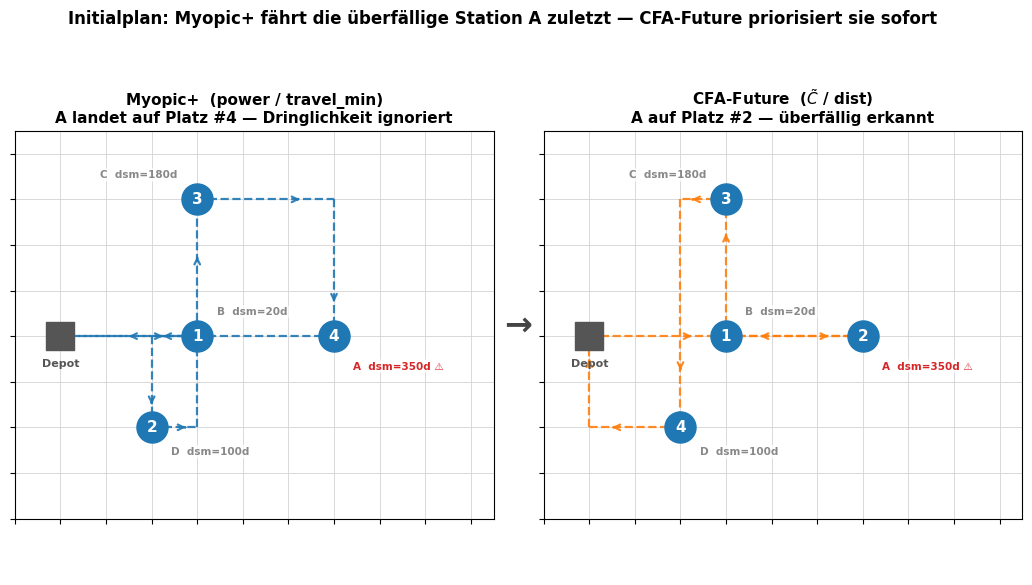

In [5]:
# ── Initialplan-Vergleich: Myopic+ vs. CFA-Future (Ulmer-Style) ─────────────
# Kernaussage: A (dsm=350d, überfällig) wird von Myopic+ zuletzt angefahren (#4),
# von CFA-Future aber früh (#2) — sichtbar allein an der Kreiszahl.

fig = plt.figure(figsize=(13, 6.5))
gs = fig.add_gridspec(1, 3, width_ratios=[10, 0.5, 10], wspace=0.04)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 2])
ax_sep = fig.add_subplot(gs[0, 1])
ax_sep.axis('off')
ax_sep.text(0.5, 0.5, '→', fontsize=24, ha='center', va='center',
            transform=ax_sep.transAxes, fontweight='bold', color='#444444')

# Welche Stationen bekommen eine dsm-Annotation (nur die für die Story relevanten)
DSM_LABELS = {
    'A': ('dsm=350d ⚠', '#d62728'),   # überfällig → rot
    'D': ('dsm=100d',   '#888888'),   # frisch → grau
    'B': ('dsm=20d',    '#888888'),
    'C': ('dsm=180d',   '#888888'),
}

for ax, route, color, subtitle in [
    (ax1, route_myopic_plus_initial,  STATION_COLOR, 'Myopic+  (power / travel_min)\nA landet auf Platz #4 — Dringlichkeit ignoriert'),
    (ax2, route_cfa_future_initial,   '#ff7f0e',     f'CFA-Future  ({C_TILDE} / dist)\nA auf Platz #2 — überfällig erkannt'),
]:
    draw_grid(ax, subtitle)
    draw_route(ax, route, color=color)
    draw_depot(ax)
    for name, s in stations.items():
        step = route.index(name) + 1
        draw_station(ax, name, label=str(step))
        label, col = DSM_LABELS[name]
        # A extra hervorheben wenn es spät dran ist
        if name == 'A' and step == 4:
            col = '#d62728'
        annotate_value(ax, name, f"{name}  {label}", color=col)

fig.suptitle(
    'Initialplan: Myopic+ fährt die überfällige Station A zuletzt — CFA-Future priorisiert sie sofort',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Interpretation: Initialplan

- **Myopic+** baut die Route nach `power_kW / travel_min(cur, node)`: ab Depot ist B (30 kW, nah) am attraktivsten (Score 5.30) → danach D (Score 7.78, sehr nah an B) → C (Score 3.48) → zuletzt **A** (Score 1.30, einzige verbleibende Station). **A — die mit `dsm=350d` bereits am stärksten überfällige (und älteste, zentralste) Station — landet ans Ende der Route**, rein weil sie weit vom Depot entfernt liegt und nur 11 kW hat. `dsm`/`recovery_curve`, `age_years` und `mean_dist` fließen **nirgends** in die Reihenfolge ein.

- **CFA-Future** baut die Route nach `(C̃ + shift) / dist(cur, node)`: ab Depot hat D den höchsten Score (8.66, `C̃_D≈-53.9` ist der zweithöchste `C̃`-Wert und D liegt nah am Depot) → danach **A** (Score 5.42 — trotz der größten Distanz im Beispiel wird A bevorzugt, weil `C̃_A≈-51.6` der höchste `C̃`-Wert aller Stationen ist: überfällig, alt, zentral gelegen) → C (`C̃_C≈-79.1`) → zuletzt B (`C̃_B≈-89.7`, kürzlich gewartet, jung, isoliert — "kann warten").

**Kernaussage:** Myopic+ ordnet die Tagesroute rein nach geometrischer Nähe und Leistung — die überfällige Station A wird zuletzt angefahren (oder bei einer Störung sogar ganz gedroppt, siehe oben). CFA-Future zieht A bewusst **nach vorne** in der Route, obwohl A weit vom Depot entfernt liegt, weil `C̃` die Dringlichkeit (`recovery_curve(dsm)`) sowie Alter und Lage der Station erfasst. Damit wird A frühzeitig bedient und ist — anders als bei Myopic+ — gegen Ende des Tages erst gar nicht mehr "in Gefahr", bei einer Störung gedroppt zu werden.

Myopic+ droppt: A  (mp_score=1.83)
CFA     droppt: D (C̃=-94.5)
  A: dsm=30d, P=11kW, mp_score=1.83, C̃=-76.8
  B: dsm=3d, P=80kW, mp_score=26.67, C̃=-56.1
  C: dsm=15d, P=22kW, mp_score=5.19, C̃=-81.6
  D: dsm=5d, P=22kW, mp_score=7.78, C̃=-94.5


/tmp/ipykernel_6147/636620156.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


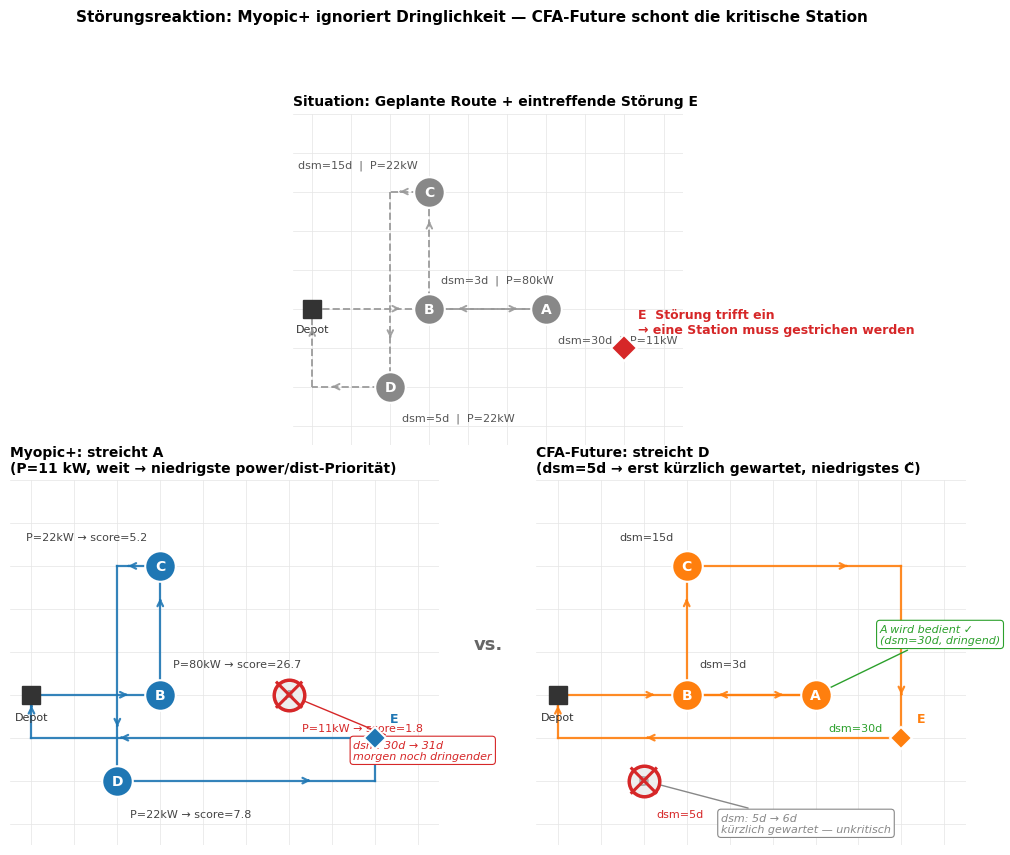

In [6]:
# ── Story-Figur: Störungsreaktion à la Ulmer (3 Panels) ──────────────────────
# Eigenständige Parameter mit realistischen dsm-Werten (~40-Tage-Simulation).
# Geplante Route: B→A→C→D. Störung E trifft ein.
# Myopic+: streicht A (P=11kW, weit → niedrigste power/dist-Priorität)
# CFA-Future: streicht D (dsm=5d → erst kürzlich gewartet, niedrigstes C̃)

_depot = (0, 3)
_st = {
    'A': {'pos': (6, 3), 'power': 11, 'dsm': 30, 'age': 12, 'mean_dist': 9},
    'B': {'pos': (3, 3), 'power': 80, 'dsm':  3, 'age':  3, 'mean_dist': 10},
    'C': {'pos': (3, 6), 'power': 22, 'dsm': 15, 'age':  8, 'mean_dist': 11},
    'D': {'pos': (2, 1), 'power': 22, 'dsm':  5, 'age':  5, 'mean_dist': 12},
}
_E_pos = (8, 2)

_REC = lambda d: 0.1 + 0.9 * min(d, 365) / 365
def _c(s):
    phi = np.array([s['power'], s['age'], _REC(s['dsm']), s['mean_dist']])
    return float(THETA @ ((phi - FEATURE_MEANS) / FEATURE_STDS))
for s in _st.values():
    s['c_tilde'] = _c(s)
    s['mp_score'] = s['power'] / max(0.1, np.hypot(s['pos'][0]-_depot[0], s['pos'][1]-_depot[1]))

_drop_mp  = min(_st, key=lambda k: _st[k]['mp_score'])
_drop_cfa = min(_st, key=lambda k: _st[k]['c_tilde'])
print(f"Myopic+ droppt: {_drop_mp}  (mp_score={_st[_drop_mp]['mp_score']:.2f})")
print(f"CFA     droppt: {_drop_cfa} (C̃={_st[_drop_cfa]['c_tilde']:.1f})")
for n, s in _st.items():
    print(f"  {n}: dsm={s['dsm']}d, P={s['power']}kW, mp_score={s['mp_score']:.2f}, C̃={s['c_tilde']:.1f}")

# ── Zeichenfunktionen ─────────────────────────────────────────────────────────
_P = {k: v['pos'] for k,v in _st.items()}
_P.update({'Depot': _depot, 'E': _E_pos})
MP_C, CFA_C, DROP_C = '#1f77b4', '#ff7f0e', '#d62728'

def _setup(ax, title):
    ax.set_xlim(-0.5, 9.5); ax.set_ylim(-0.5, 8.0)
    ax.set_aspect('equal'); ax.axis('off')
    for x in range(10): ax.axvline(x, color='#e5e5e5', lw=0.5, zorder=0)
    for y in range(9):  ax.axhline(y, color='#e5e5e5', lw=0.5, zorder=0)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6, loc='left')

def _depot_marker(ax):
    ax.plot(*_depot, 's', color='#333', ms=13, zorder=5)
    ax.text(_depot[0], _depot[1]-0.6, 'Depot', fontsize=8, ha='center', color='#333')

def _manhattan(ax, pts, col, ls='-', lw=1.6, alpha=0.9):
    for i in range(len(pts)-1):
        x1,y1=pts[i]; x2,y2=pts[i+1]
        segs = []
        if x1!=x2: segs.append(((x1,y1),(x2,y1)))
        if y1!=y2: segs.append(((x2,y1),(x2,y2)))
        for (a,b),(c,d) in segs:
            ax.plot([a,c],[b,d], color=col, lw=lw, ls=ls, alpha=alpha, zorder=2)
            ax.annotate('', xy=(a*.25+c*.75, b*.25+d*.75),
                        xytext=(a*.27+c*.73, b*.27+d*.73),
                        arrowprops=dict(arrowstyle='->', color=col, lw=lw, alpha=alpha), zorder=3)

def _circle(ax, name, fill_color, dropped=False):
    pos = _P[name]
    if dropped:
        ax.plot(*pos, 'o', color='#eeeeee', ms=22, zorder=4,
                markeredgecolor=DROP_C, markeredgewidth=2.5)
        ax.text(*pos, name, ha='center', va='center', fontsize=10,
                fontweight='bold', color='#aaaaaa', zorder=5)
        # Kreuz durch den Kreis
        for dx,dy in [(-0.28,0.28),(0.28,0.28)]:
            ax.plot([pos[0]-dx,pos[0]+dx],[pos[1]-dy,pos[1]+dy],
                    color=DROP_C, lw=2.2, zorder=6)
    else:
        ax.plot(*pos, 'o', color=fill_color, ms=22, zorder=4,
                markeredgecolor='white', markeredgewidth=1.5)
        ax.text(*pos, name, ha='center', va='center', fontsize=10,
                fontweight='bold', color='white', zorder=5)

# Stationsspezifische Label-Offsets (verhindert Überlapp mit Routen)
_OFFSETS = {
    'A': (0.3, -0.65), 'B': (0.3,  0.6),
    'C': (-0.3, 0.55), 'D': (0.3, -0.65),
}
def _lbl(ax, name, text, color='#444444'):
    dx, dy = _OFFSETS[name]
    pos = _P[name]
    va = 'bottom' if dy > 0 else 'top'
    ha = 'right' if dx < 0 else 'left'
    ax.text(pos[0]+dx, pos[1]+dy, text, fontsize=8, color=color, ha=ha, va=va)

def _E_marker(ax, col):
    ax.plot(*_E_pos, 'D', color=col, ms=11, zorder=5,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.text(_E_pos[0]+0.35, _E_pos[1]+0.3, 'E', fontsize=9,
            fontweight='bold', color=col, ha='left', va='bottom', zorder=6)

def _callout(ax, pos, text, color, x_off, y_off):
    ax.annotate(text, xy=pos, xytext=(pos[0]+x_off, pos[1]+y_off),
                fontsize=8, color=color, style='italic',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.0),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=0.8))

# ── Figure-Layout: 2 Zeilen, Top spannt volle Breite ─────────────────────────
fig = plt.figure(figsize=(13, 9.5))
gs = fig.add_gridspec(2, 3, width_ratios=[10, 0.4, 10],
                      height_ratios=[1, 1.1], hspace=0.1, wspace=0.04)
ax_top = fig.add_subplot(gs[0, :])
ax_bl  = fig.add_subplot(gs[1, 0])
ax_br  = fig.add_subplot(gs[1, 2])
ax_vs  = fig.add_subplot(gs[1, 1]); ax_vs.axis('off')
ax_vs.text(0.5, 0.55, 'vs.', fontsize=13, ha='center', va='center',
           transform=ax_vs.transAxes, fontweight='bold', color='#666666')

_planned = ['B', 'A', 'C', 'D']

# ─── TOP: Ausgangssituation ──────────────────────────────────────────────────
_setup(ax_top, 'Situation: Geplante Route + eintreffende Störung E')
_depot_marker(ax_top)
_manhattan(ax_top, [_depot]+[_P[n] for n in _planned]+[_depot], '#999999', ls='--', lw=1.4)
for name, s in _st.items():
    _circle(ax_top, name, '#888888')
    _lbl(ax_top, name, f"dsm={s['dsm']}d  |  P={s['power']}kW", color='#555555')
ax_top.plot(*_E_pos, 'D', color=DROP_C, ms=13, zorder=6, markeredgecolor='white', markeredgewidth=1.5)
ax_top.text(_E_pos[0]+0.35, _E_pos[1]+0.3,
            'E  Störung trifft ein\n→ eine Station muss gestrichen werden',
            fontsize=9, color=DROP_C, fontweight='bold', ha='left', va='bottom')

# ─── UNTEN LINKS: Myopic+ ────────────────────────────────────────────────────
_setup(ax_bl, 'Myopic+: streicht A\n(P=11 kW, weit → niedrigste power/dist-Priorität)')
_depot_marker(ax_bl)
_manhattan(ax_bl, [_depot]+[_P[n] for n in ['B','C','D']]+[_E_pos]+[_depot], MP_C)
for name, s in _st.items():
    _circle(ax_bl, name, MP_C, dropped=(name=='A'))
    col = DROP_C if name=='A' else '#444444'
    _lbl(ax_bl, name, f"P={s['power']}kW → score={s['mp_score']:.1f}", color=col)
_E_marker(ax_bl, MP_C)
_callout(ax_bl, _P['A'], 'dsm: 30d → 31d\nmorgen noch dringender', DROP_C, +1.5, -1.5)

# ─── UNTEN RECHTS: CFA-Future ────────────────────────────────────────────────
_setup(ax_br, 'CFA-Future: streicht D\n(dsm=5d → erst kürzlich gewartet, niedrigstes C̃)')
_depot_marker(ax_br)
_manhattan(ax_br, [_depot]+[_P[n] for n in ['B','A','C']]+[_E_pos]+[_depot], CFA_C)
for name, s in _st.items():
    _circle(ax_br, name, CFA_C, dropped=(name=='D'))
    col = DROP_C if name=='D' else ('#2ca02c' if name=='A' else '#444444')
    _lbl(ax_br, name, f"dsm={s['dsm']}d", color=col)
_E_marker(ax_br, CFA_C)
_callout(ax_br, _P['D'], 'dsm: 5d → 6d\nkürzlich gewartet — unkritisch', '#888888', +1.8, -1.2)
_callout(ax_br, _P['A'], 'A wird bedient ✓\n(dsm=30d, dringend)', '#2ca02c', +1.5, +1.2)

fig.suptitle(
    'Störungsreaktion: Myopic+ ignoriert Dringlichkeit — CFA-Future schont die kritische Station',
    fontsize=11, fontweight='bold', y=0.99
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

/tmp/ipykernel_6147/528637894.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


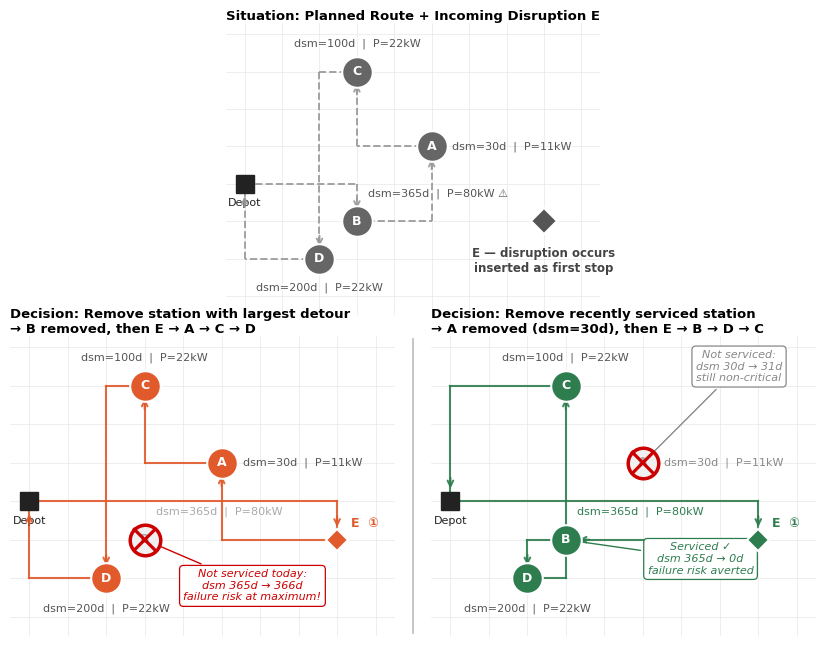

In [7]:
# ── Illustrative figure: two drop strategies ─────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

_d = (0, 3)
_s = {
    'A': {'pos': (5, 4), 'dsm':  30, 'power': 11},
    'B': {'pos': (3, 2), 'dsm': 365, 'power': 80},
    'C': {'pos': (3, 6), 'dsm': 100, 'power': 22},
    'D': {'pos': (2, 1), 'dsm': 200, 'power': 22},
}
_E = (8, 2)
_planned = ['B', 'A', 'C', 'D']

C1 = '#e05a2b'
C2 = '#2e7d4f'

def _grid(ax, title=''):
    ax.set_xlim(-0.5, 9.5); ax.set_ylim(-0.5, 7.3)
    ax.set_aspect('equal'); ax.axis('off')
    for x in range(10): ax.axvline(x, color='#e8e8e8', lw=0.5, zorder=0)
    for y in range(9):  ax.axhline(y, color='#e8e8e8', lw=0.5, zorder=0)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight='bold', pad=2, loc='left')

def _depot(ax):
    ax.plot(*_d, 's', color='#222', ms=13, zorder=6)
    ax.text(_d[0], _d[1]-0.6, 'Depot', fontsize=8, ha='center', color='#222')

def _route(ax, waypoints, col, ls='-', lw=1.5, alpha=0.9):
    LANE   = 0.11
    NODE_R = 0.33
    SHAFT  = 0.28
    edge_data = []
    for i in range(len(waypoints)-1):
        x1,y1=waypoints[i]; x2,y2=waypoints[i+1]
        segs=[]
        if x1!=x2: segs.append(('h', x1, y1, x2, y1))
        if y1!=y2: segs.append(('v', x2, y1, x2, y2))
        edge_data.append(segs)
    taken_h = {}; taken_v = {}; edge_offs = []
    for segs in edge_data:
        seg_offs = []
        for typ, x1, y1, x2, y2 in segs:
            off = 0.0
            if typ == 'h':
                xmin, xmax = min(x1,x2), max(x1,x2)
                key = round(y1, 4)
                for ex0, ex1, eoff in taken_h.get(key, []):
                    if xmin < ex1 and xmax > ex0:
                        off = LANE if eoff <= 0 else -LANE; break
                taken_h.setdefault(key, []).append((xmin, xmax, off))
            else:
                ymin, ymax = min(y1,y2), max(y1,y2)
                key = round(x1, 4)
                for ey0, ey1, eoff in taken_v.get(key, []):
                    if ymin < ey1 and ymax > ey0:
                        off = LANE if eoff <= 0 else -LANE; break
                taken_v.setdefault(key, []).append((ymin, ymax, off))
            seg_offs.append(off)
        edge_offs.append(seg_offs)
    for i, segs in enumerate(edge_data):
        drawn = []; prev_end = None
        for j, (typ, x1, y1, x2, y2) in enumerate(segs):
            off = edge_offs[i][j]
            if typ == 'h': ax1,ay1,ax2,ay2 = x1,y1+off,x2,y2+off
            else:           ax1,ay1,ax2,ay2 = x1+off,y1,x2+off,y2
            if prev_end is not None and j > 0: ax1,ay1 = prev_end
            ax.plot([ax1,ax2],[ay1,ay2], color=col,lw=lw,ls=ls,alpha=alpha,zorder=2)
            drawn.append((ax1,ay1,ax2,ay2)); prev_end=(ax2,ay2)
        if drawn:
            dx1,dy1,dx2,dy2=drawn[-1]
            sdx,sdy=dx2-dx1,dy2-dy1; slen=max(np.hypot(sdx,sdy),0.01)
            ddx,ddy=sdx/slen,sdy/slen
            tip =(dx2-ddx*NODE_R,          dy2-ddy*NODE_R)
            tail=(dx2-ddx*(NODE_R+SHAFT),  dy2-ddy*(NODE_R+SHAFT))
            ax.annotate('', xy=tip, xytext=tail,
                        arrowprops=dict(arrowstyle='->', color=col,
                                        lw=lw, alpha=alpha, shrinkA=0, shrinkB=0), zorder=3)

def _station(ax, name, col, dropped=False, label='', label_col='#333'):
    pos = _s[name]['pos']
    if dropped:
        ax.plot(*pos, 'o', color='#f0f0f0', ms=22, zorder=4,
                markeredgecolor='#cc0000', markeredgewidth=2.5)
        ax.text(*pos, name, ha='center', va='center', fontsize=9,
                fontweight='bold', color='#aaaaaa', zorder=5)
        d_ = 0.27
        for sgn in [1,-1]:
            ax.plot([pos[0]-d_,pos[0]+d_],[pos[1]-sgn*d_,pos[1]+sgn*d_],
                    color='#cc0000', lw=2.3, zorder=6)
    else:
        ax.plot(*pos, 'o', color=col, ms=22, zorder=4,
                markeredgecolor='white', markeredgewidth=1.5)
        ax.text(*pos, name, ha='center', va='center', fontsize=9,
                fontweight='bold', color='white', zorder=5)
    if label:
        dx,dy,ha,va = {'A':(0.55, 0.0,'left','center'),'B':(0.3,0.6,'left','bottom'),
                         'C':(0.0, 0.60,'center','bottom'),'D':(0.0,-0.65,'center','top')}[name]
        ax.text(pos[0]+dx, pos[1]+dy, label, fontsize=8, color=label_col, ha=ha, va=va)

def _situation(ax, col, highlight_drop, planned=None):
    """Planned route + disruption E. highlight_drop: station name to annotate as drop candidate."""
    _depot(ax)
    _route(ax, [_d]+[_s[n]['pos'] for n in (planned or _planned)]+[_d], '#999', ls='--', lw=1.4)
    for n,s in _s.items():
        warn = ' ⚠' if n=='B' else ''
        _station(ax, n, '#888888',
                 label=f"dsm={s['dsm']}d  |  P={s['power']}kW{warn}", label_col='#555')
    ax.plot(*_E,'D',color=col,ms=13,zorder=6,markeredgecolor='white',markeredgewidth=1.5)
    ax.text(_E[0], _E[1]-0.7,
            'E — disruption occurs\ninserted as first stop',
            fontsize=8.5, color=col, fontweight='bold', ha='center', va='top')
    # annotate which station will be dropped
    drop_pos = _s[highlight_drop]['pos']
    if highlight_drop == 'B':
        txt_xy = (drop_pos[0]+1.8, drop_pos[1]-1.2)
        arrowkw = dict(arrowstyle='->', color=col, lw=1.0)
    else:
        txt_xy = (drop_pos[0], drop_pos[1]+1.1)
        arrowkw = dict(arrowstyle='->', color=col, lw=1.0)
    ax.annotate(f'→ {highlight_drop} removed',
                xy=drop_pos, xytext=txt_xy,
                fontsize=8, color=col, style='italic',
                ha='center' if highlight_drop != 'B' else 'left',
                arrowprops=arrowkw)

def _E_dot(ax, col):
    ax.plot(*_E, 'D', color=col, ms=11, zorder=5,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.text(_E[0]+0.35, _E[1]+0.25, 'E  ①', fontsize=9,
            fontweight='bold', color=col, ha='left', va='bottom')

def _note(ax, pos, text, col, x_off, y_off):
    ax.annotate(text, xy=pos, xytext=(pos[0]+x_off, pos[1]+y_off),
                fontsize=8, color=col, style='italic', ha='center', va='center',
                arrowprops=dict(arrowstyle='->', color=col, lw=1.0),
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=col, lw=0.9))

# ── Layout: 2×3  (top: shared situation centered; bottom: decision | sep | decision)
fig = plt.figure(figsize=(10.4, 8.0))
gs = GridSpec(2, 3, figure=fig, width_ratios=[10, 0.4, 10],
              height_ratios=[1, 1.05], hspace=0.06, wspace=0.04)
ax_top = fig.add_subplot(gs[0, :])   # shared situation, full width → recentered below
ax_bl  = fig.add_subplot(gs[1, 0])
ax_br  = fig.add_subplot(gs[1, 2])
ax_m   = fig.add_subplot(gs[1, 1]); ax_m.axis('off')
ax_m.plot([0.5, 0.5], [0.02, 0.98], color='#bbbbbb', lw=1.2, transform=ax_m.transAxes, clip_on=False)

# ─── Top: shared situation (neutral, no drop annotation) ─────────────────────
_grid(ax_top, 'Situation: Planned Route + Incoming Disruption E')
_depot(ax_top)
_route(ax_top, [_d]+[_s[n]['pos'] for n in _planned]+[_d], '#999', ls='--', lw=1.4)
for n, s in _s.items():
    warn = ' ⚠' if n == 'B' else ''
    _station(ax_top, n, '#666666',
             label=f"dsm={s['dsm']}d  |  P={s['power']}kW{warn}", label_col='#555')
ax_top.plot(*_E, 'D', color='#555', ms=13, zorder=6,
            markeredgecolor='white', markeredgewidth=1.5)
ax_top.text(_E[0], _E[1]-0.7, 'E — disruption occurs\ninserted as first stop',
            fontsize=8.5, color='#444', fontweight='bold', ha='center', va='top')

# ─── Bottom left: drop by routing efficiency ──────────────────────────────────
_grid(ax_bl, 'Decision: Remove station with largest detour\n→ B removed, then E → A → C → D')
_depot(ax_bl)
_route(ax_bl, [_d, _E, _s['A']['pos'], _s['C']['pos'], _s['D']['pos'], _d], C1)
for n in _s:
    _station(ax_bl, n, C1, dropped=(n=='B'),
             label=f"dsm={_s[n]['dsm']}d  |  P={_s[n]['power']}kW",
             label_col='#aaaaaa' if n=='B' else '#555555')
_E_dot(ax_bl, C1)
_note(ax_bl, _s['B']['pos'],
      'Not serviced today:\ndsm 365d → 366d\nfailure risk at maximum!',
      '#cc0000', +2.8, -1.2)

# ─── Bottom right: drop by maintenance urgency ────────────────────────────────
_grid(ax_br, 'Decision: Remove recently serviced station\n→ A removed (dsm=30d), then E → B → D → C')
_depot(ax_br)
_route(ax_br, [_d, _E, _s['B']['pos'], _s['D']['pos'], _s['C']['pos'], _d], C2)
for n in _s:
    label_col = C2 if n=='B' else ('#888888' if n=='A' else '#555555')
    _station(ax_br, n, C2, dropped=(n=='A'),
             label=f"dsm={_s[n]['dsm']}d  |  P={_s[n]['power']}kW",
             label_col=label_col)
_E_dot(ax_br, C2)
_note(ax_br, _s['A']['pos'],
      'Not serviced:\ndsm 30d → 31d\nstill non-critical',
      '#888888', +2.5, +2.5)
_note(ax_br, _s['B']['pos'],
      'Serviced ✓\ndsm 365d → 0d\nfailure risk averted',
      C2, +3.5, -0.5)

plt.tight_layout()

# Center ax_top to same width as one bottom panel
pos_bl = ax_bl.get_position()
pos_br = ax_br.get_position()
cx = (pos_bl.x0 + pos_br.x1) / 2
pw = pos_bl.width
pt = ax_top.get_position()
ax_top.set_position([cx - pw/2, pt.y0, pw, pt.height])

plt.show()


/tmp/ipykernel_6147/1617718022.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


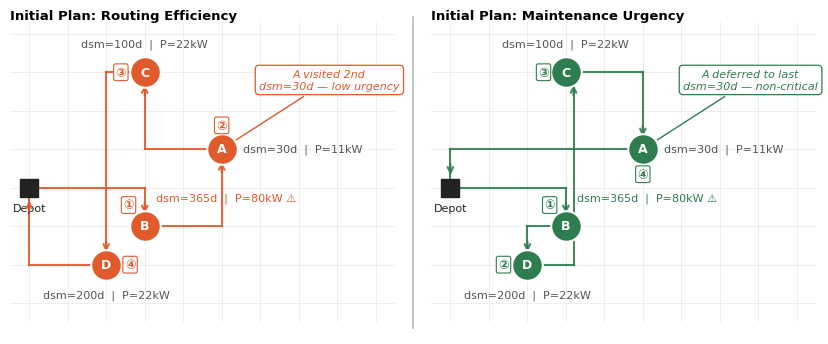

In [8]:
# ── Illustrative figure: Initial Plan comparison ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

_d = (0, 3)
_s = {
    'A': {'pos': (5, 4), 'dsm':  30, 'power': 11},
    'B': {'pos': (3, 2), 'dsm': 365, 'power': 80},
    'C': {'pos': (3, 6), 'dsm': 100, 'power': 22},
    'D': {'pos': (2, 1), 'dsm': 200, 'power': 22},
}
C1 = '#e05a2b'
C2 = '#2e7d4f'
_plan_eff = ['B', 'A', 'C', 'D']
_plan_urg = ['B', 'D', 'C', 'A']

def _grid(ax, title=''):
    ax.set_xlim(-0.5, 9.5); ax.set_ylim(-0.5, 7.3)
    ax.set_aspect('equal'); ax.axis('off')
    for x in range(10): ax.axvline(x, color='#e8e8e8', lw=0.5, zorder=0)
    for y in range(9):  ax.axhline(y, color='#e8e8e8', lw=0.5, zorder=0)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight='bold', pad=2, loc='left')

def _depot(ax):
    ax.plot(*_d, 's', color='#222', ms=13, zorder=6)
    ax.text(_d[0], _d[1]-0.6, 'Depot', fontsize=8, ha='center', color='#222')

def _route(ax, waypoints, col, ls='-', lw=1.5, alpha=0.9):
    LANE   = 0.20
    NODE_R = 0.33
    SHAFT  = 0.28
    edge_data = []
    for i in range(len(waypoints)-1):
        x1,y1=waypoints[i]; x2,y2=waypoints[i+1]
        segs=[]
        if x1!=x2: segs.append(('h', x1, y1, x2, y1))
        if y1!=y2: segs.append(('v', x2, y1, x2, y2))
        edge_data.append(segs)
    taken_h = {}; taken_v = {}; edge_offs = []
    for segs in edge_data:
        seg_offs = []
        for typ, x1, y1, x2, y2 in segs:
            off = 0.0
            if typ == 'h':
                xmin, xmax = min(x1,x2), max(x1,x2)
                key = round(y1, 4)
                for ex0, ex1, eoff in taken_h.get(key, []):
                    if xmin < ex1 and xmax > ex0:
                        off = LANE if eoff <= 0 else -LANE; break
                taken_h.setdefault(key, []).append((xmin, xmax, off))
            else:
                ymin, ymax = min(y1,y2), max(y1,y2)
                key = round(x1, 4)
                for ey0, ey1, eoff in taken_v.get(key, []):
                    if ymin < ey1 and ymax > ey0:
                        off = LANE if eoff <= 0 else -LANE; break
                taken_v.setdefault(key, []).append((ymin, ymax, off))
            seg_offs.append(off)
        edge_offs.append(seg_offs)
    for i, segs in enumerate(edge_data):
        drawn = []; prev_end = None
        for j, (typ, x1, y1, x2, y2) in enumerate(segs):
            off = edge_offs[i][j]
            if typ == 'h': ax1,ay1,ax2,ay2 = x1,y1+off,x2,y2+off
            else:           ax1,ay1,ax2,ay2 = x1+off,y1,x2+off,y2
            if prev_end is not None and j > 0:
                if typ == 'h':
                    if abs(prev_end[1] - ay1) > 1e-4:
                        ax.plot([prev_end[0], prev_end[0]], [prev_end[1], ay1],
                                color=col, lw=lw, ls=ls, alpha=alpha, zorder=2)
                    ax1 = prev_end[0]
                else:
                    if abs(prev_end[0] - ax1) > 1e-4:
                        ax.plot([prev_end[0], ax1], [prev_end[1], prev_end[1]],
                                color=col, lw=lw, ls=ls, alpha=alpha, zorder=2)
                    ay1 = prev_end[1]
            ax.plot([ax1,ax2],[ay1,ay2], color=col,lw=lw,ls=ls,alpha=alpha,zorder=2)
            drawn.append((ax1,ay1,ax2,ay2)); prev_end=(ax2,ay2)
        if drawn:
            dx1,dy1,dx2,dy2=drawn[-1]
            sdx,sdy=dx2-dx1,dy2-dy1; slen=max(np.hypot(sdx,sdy),0.01)
            ddx,ddy=sdx/slen,sdy/slen
            tip =(dx2-ddx*NODE_R,         dy2-ddy*NODE_R)
            tail=(dx2-ddx*(NODE_R+SHAFT),  dy2-ddy*(NODE_R+SHAFT))
            ax.annotate('', xy=tip, xytext=tail,
                        arrowprops=dict(arrowstyle='->', color=col,
                                        lw=lw, alpha=alpha, shrinkA=0, shrinkB=0), zorder=3)

def _station(ax, name, col, label='', label_col='#555'):
    pos = _s[name]['pos']
    ax.plot(*pos, 'o', color=col, ms=22, zorder=4,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.text(*pos, name, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', zorder=5)
    if label:
        dx,dy,ha,va = {'A':(0.55, 0.0,'left','center'),'B':(0.3,0.6,'left','bottom'),
                       'C':(0.0, 0.60,'center','bottom'),'D':(0.0,-0.65,'center','top')}[name]
        ax.text(pos[0]+dx, pos[1]+dy, label, fontsize=8, color=label_col, ha=ha, va=va)

_ORDER_OFF = {
    'A': (-0.58,  0.0),
    'B': (-0.42,  0.55),
    'C': (-0.58,  0.0),
    'D': (-0.42, -0.55),
}
_NUMS = ['①','②','③','④']

def _order(ax, name, idx, col, ox=None, oy=None):
    pos = _s[name]['pos']
    if ox is None: ox, oy = _ORDER_OFF[name]
    ax.text(pos[0]+ox, pos[1]+oy, _NUMS[idx], fontsize=9, color=col,
            fontweight='bold', ha='center', va='center', zorder=7,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=col, lw=0.8))

def _note(ax, pos, text, col, x_off, y_off):
    ax.annotate(text, xy=pos, xytext=(pos[0]+x_off, pos[1]+y_off),
                fontsize=8, color=col, style='italic', ha='center', va='center',
                arrowprops=dict(arrowstyle='->', color=col, lw=1.0),
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=col, lw=0.9))

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10.4, 4.2))
gs = GridSpec(1, 3, figure=fig, width_ratios=[10, 0.4, 10], wspace=0.04)
ax_l = fig.add_subplot(gs[0, 0])
ax_r = fig.add_subplot(gs[0, 2])
ax_m = fig.add_subplot(gs[0, 1]); ax_m.axis('off')
ax_m.plot([0.5, 0.5], [0.02, 0.98], color='#bbbbbb', lw=1.2,
          transform=ax_m.transAxes, clip_on=False)

# ── Left: routing-efficient plan ──────────────────────────────────────────────
_grid(ax_l, 'Initial Plan: Routing Efficiency')
_depot(ax_l)
_route(ax_l, [_d]+[_s[n]['pos'] for n in _plan_eff]+[_d], C1)
for i, n in enumerate(_plan_eff):
    warn = ' ⚠' if n == 'B' else ''
    _station(ax_l, n, C1,
             label=f"dsm={_s[n]['dsm']}d  |  P={_s[n]['power']}kW{warn}",
             label_col=C1 if n == 'B' else '#555')
    off_l = {'A': (0, +0.62), 'C': (-0.62, 0), 'D': (+0.62, 0)}
    _order(ax_l, n, i, C1, **({'ox': off_l[n][0], 'oy': off_l[n][1]} if n in off_l else {}))
_note(ax_l, _s['A']['pos'],
      'A visited 2nd\ndsm=30d — low urgency',
      C1, +2.8, +1.8)

# ── Right: urgency-aware plan ─────────────────────────────────────────────────
_grid(ax_r, 'Initial Plan: Maintenance Urgency')
_depot(ax_r)
_route(ax_r, [_d]+[_s[n]['pos'] for n in _plan_urg]+[_d], C2)
for i, n in enumerate(_plan_urg):
    warn = ' ⚠' if n == 'B' else ''
    _station(ax_r, n, C2,
             label=f"dsm={_s[n]['dsm']}d  |  P={_s[n]['power']}kW{warn}",
             label_col=C2 if n == 'B' else '#555')
    off_r = {'D': (-0.62, 0), 'A': (0, -0.65)}
    _order(ax_r, n, i, C2, **({'ox': off_r[n][0], 'oy': off_r[n][1]} if n in off_r else {}))
_note(ax_r, _s['A']['pos'],
      'A deferred to last\ndsm=30d — non-critical',
      C2, +2.8, +1.8)

plt.tight_layout()
plt.show()
